In [7]:
from scipy.optimize import curve_fit
import matplotlib.pylab as plt
import numpy as np
import os


In [18]:
from uncertainties import ufloat
a = ufloat(best_fit_ab[0], sigma_ab[0])
b = ufloat(best_fit_ab[1], sigma_ab[1])
c = ufloat(best_fit_ab[2], sigma_ab[2])
text_res = "Best-fit (polanomic) parameters: \na = {}\nb = {}".format(a, b, c)
print(text_res)

a2 = ufloat(best_fit_ab2[0], sigma_ab2[0])
b2 = ufloat(best_fit_ab2[1], sigma_ab2[1])
c2 = ufloat(best_fit_ab2[2], sigma_ab2[2])
text_res2 = "Best-fit (polynomic) parameters: \na = {}\nb = {}".format(a2, b2, c2)
print(text_res2)

a3 = ufloat(best_fit_ab3[0], sigma_ab3[0])
b3 = ufloat(best_fit_ab3[1], sigma_ab3[1])
c3 = ufloat(best_fit_ab3[2], sigma_ab3[2])
text_res3 = "Best-fit (polynomic) parameters: \na = {}\nb = {}".format(a3, b3, c3)
print(text_res3)

a4 = ufloat(best_fit_ab4[0], sigma_ab4[0])
b4 = ufloat(best_fit_ab4[1], sigma_ab4[1])
c4 = ufloat(best_fit_ab4[2], sigma_ab4[2])
text_res4 = "Best-fit parameters: \na = {}\nb = {}".format(a4, b4, c4)
print(text_res4)

Best-fit (polanomic) parameters: 
a = (-9.6+/-2.1)e-05
b = 0.0357+/-0.0020
Best-fit (polynomic) parameters: 
a = (-5.1+/-2.1)e-05
b = 0.0234+/-0.0020
Best-fit (polynomic) parameters: 
a = -0.000135+/-0.000018
b = 0.0467+/-0.0017
Best-fit parameters: 
a = (-4.9+/-1.8)e-05
b = 0.0272+/-0.0017


In [19]:
# plotting the unaveraged data
#flier_kwargs = dict(marker = 'o', markerfacecolor = 'silver',
#                    markersize = 3, alpha=0.7)
#line_kwargs = dict(color = 'k', linewidth = 1)

#bp = plt.boxplot(y_data, positions = x_data,
#                 capprops = line_kwargs,
#                 boxprops = line_kwargs,
#                 whiskerprops = line_kwargs,
#                 medianprops = line_kwargs,
#                 flierprops = flier_kwargs,
#                 widths = 5,
#                 manage_ticks = False)

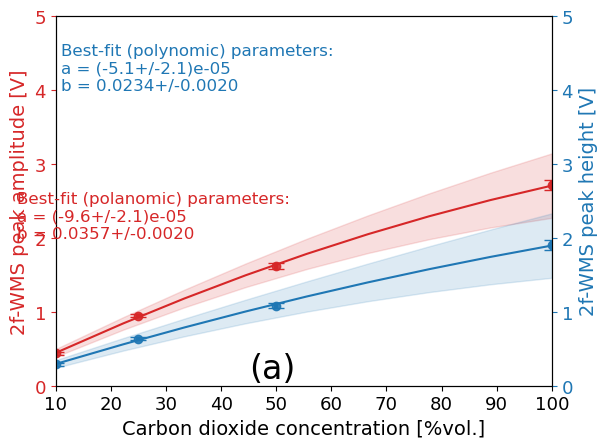

In [20]:
0

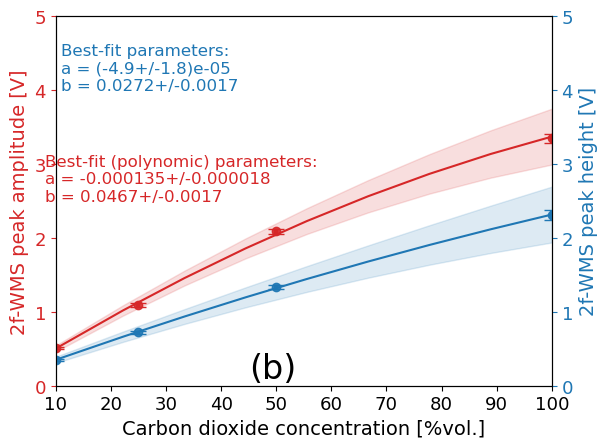

In [21]:
fig, ax3 = plt.subplots()

color = 'tab:red'
ax3.set_xlabel('Carbon dioxide concentration [%vol.]', fontsize=14)
ax3.set_ylabel('2f-WMS peak amplitude [V]', color=color, fontsize=14)
ax3.tick_params(axis='y', labelcolor=color)

#plt.errorbar(x_data, y_means, y_spread, fmt = 'none', ecolor = 'black')
ax3.errorbar(x_data, B_2f, y1_spread, fmt='none', linewidth=3, capsize=6, ecolor = 'tab:red')
# plotting the averaged data with calculated dispersion
ax3.scatter(x_data, B_2f, marker='o', facecolor = 'tab:red', alpha = 0.9)

# plotting the model, 
hires_x = np.linspace(0, 100, 10)
ax3.plot(hires_x, func(hires_x, *best_fit_ab3), 'tab:red')
bound_upper = func(hires_x, *(best_fit_ab3 + sigma_ab3))
bound_lower = func(hires_x, *(best_fit_ab3 - sigma_ab3))
# plotting the confidence intervals
ax3.fill_between(hires_x, bound_lower, bound_upper,
                 color = 'tab:red', alpha = 0.15)
ax3.tick_params(axis ='y', which ='major',  
               labelsize = 13, colors ='tab:red')
ax3.tick_params(axis ='x', which ='major', labelsize = 13)

plt.xlim(10, 100)
plt.ylim(0, 5)

ax4 = ax3.twinx()  # instantiate a second axes that shares the same x-axis

color2 = 'tab:blue'
ax4.set_ylabel('2f-WMS peak height [V]', color=color2, fontsize=14)  # we already handled the x-label with ax1
ax4.tick_params(axis='y', labelcolor=color2)

#plt.errorbar(x_data, y_means, y_spread, fmt = 'none', ecolor = 'black')
ax4.errorbar(x_data, G_2f, y1_spread, fmt='none', linewidth=3, capsize=6, ecolor = 'tab:blue')
# plotting the averaged data with calculated dispersion
ax4.scatter(x_data, G_2f, marker='o', facecolor = 'tab:blue', alpha = 0.9)

# plotting the model
hires_x = np.linspace(0, 100, 10)
ax4.plot(hires_x, func(hires_x, *best_fit_ab4), 'tab:blue')
bound_upper = func(hires_x, *(best_fit_ab4 + sigma_ab4))
bound_lower = func(hires_x, *(best_fit_ab4 - sigma_ab4))
# plotting the confidence intervals
ax4.fill_between(hires_x, bound_lower, bound_upper,
                 color = 'tab:blue', alpha = 0.15)
ax4.tick_params(axis ='y', which ='major',  
               labelsize = 13, colors ='tab:blue')
ax4.tick_params(axis ='x', which ='major', labelsize = 13)

plt.xlim(10, 100)
plt.ylim(0, 5)

plt.text(8, 2.5, text_res3, color = 'tab:red', fontsize=12)
plt.text(11, 4, text_res4, color = 'tab:blue', fontsize=12)
plt.text(45, 0.1, "(b)", fontsize=24)


#plt.gcf().set_size_inches(6,6)
plt.savefig("best-fit_unc_A1.png", dpi=600, bbox_inches='tight')
plt.savefig("best-fit_unc_A1.pdf", dpi=600, bbox_inches='tight')
plt.show()